In [1]:
# ==========================================
# Menghubungkan Google Drive
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
dataset_path = '/content/drive/MyDrive/2307033_AzkiaAlHikam_UAS_S6/dfTransjakarta.csv'

# ============================================================
# B.1 LOAD DATASET
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv(dataset_path)

print('=== INFORMASI DATASET MENTAH ===')
print(f'Jumlah Baris & Kolom: {df_raw.shape}')
print(f'\nKolom tersedia: {list(df_raw.columns)}')
print('\nInfo Tipe Data:')
df_raw.info()

=== INFORMASI DATASET MENTAH ===
Jumlah Baris & Kolom: (37900, 22)

Kolom tersedia: ['transID', 'payCardID', 'payCardBank', 'payCardName', 'payCardSex', 'payCardBirthDate', 'corridorID', 'corridorName', 'direction', 'tapInStops', 'tapInStopsName', 'tapInStopsLat', 'tapInStopsLon', 'stopStartSeq', 'tapInTime', 'tapOutStops', 'tapOutStopsName', 'tapOutStopsLat', 'tapOutStopsLon', 'stopEndSeq', 'tapOutTime', 'payAmount']

Info Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37900 entries, 0 to 37899
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transID           37900 non-null  object 
 1   payCardID         37900 non-null  int64  
 2   payCardBank       37900 non-null  object 
 3   payCardName       37900 non-null  object 
 4   payCardSex        37900 non-null  object 
 5   payCardBirthDate  37900 non-null  int64  
 6   corridorID        36643 non-null  object 
 7   corridorName      35970 

In [3]:
# ============================================================
# INSTALASI LIBRARY
# ============================================================
!pip install streamlit pandas numpy matplotlib seaborn scikit-learn plotly -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 89.1 MB/s eta 0:00:00


In [4]:
# ============================================================
# B.2 PENGECEKAN MISSING VALUE & STATISTIK DESKRIPTIF
# ============================================================
print('=== MISSING VALUE ===')
missing = df_raw.isnull().sum()
print(missing[missing > 0])

print('\n=== STATISTIK DESKRIPTIF ===')
display(df_raw.describe())

print('\n=== SAMPLE DATA (5 Baris Pertama) ===')
display(df_raw.head())

=== MISSING VALUE ===
corridorID         1257
corridorName       1930
tapInStops         1213
tapOutStops        2289
tapOutStopsName    1344
tapOutStopsLat     1344
tapOutStopsLon     1344
stopEndSeq         1344
tapOutTime         1344
payAmount          1007
dtype: int64

=== STATISTIK DESKRIPTIF ===


,payCardID,payCardBirthDate,direction,tapInStopsLat,tapInStopsLon,stopStartSeq,tapOutStopsLat,tapOutStopsLon,stopEndSeq,payAmount
count,3.790000e+04,37900.000000,37900.000000,37900.000000,37900.000000,37900.000000,36556.000000,36556.000000,36556.000000,36893.000000
mean,4.250060e+17,1990.089314,0.500633,-6.214838,106.841554,13.572480,-6.214651,106.841233,21.219909,2699.712683
std,1.321699e+18,13.051482,0.500006,0.057911,0.060369,12.237623,0.059022,0.060999,13.800689,4212.225592
min,6.040368e+10,1946.000000,0.000000,-6.394973,106.614730,0.000000,-6.394973,106.614730,1.000000,0.000000
25%,1.800442e+14,1982.000000,0.000000,-6.245863,106.803470,4.000000,-6.247225,106.801750,11.000000,0.000000
50%,3.507947e+15,1990.000000,1.000000,-6.214587,106.834830,10.000000,-6.214718,106.834580,18.000000,3500.000000
75%,4.699023e+15,2001.000000,1.000000,-6.175528,106.882270,19.000000,-6.174736,106.883030,29.000000,3500.000000
max,4.997694e+18,2012.000000,1.000000,-6.089429,107.023950,68.000000,-6.091746,107.023660,77.000000,20000.000000



=== SAMPLE DATA (5 Baris Pertama) ===


,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount
0,EIIW227B8L34VB,180062659848800,emoney,Bajragin Usada,M,2008,5,Matraman Baru - Ancol,1.0,P00142,...,106.84402,7,2023-04-03 05:21:44,P00253,Tegalan,-6.203101,106.85715,12.0,2023-04-03 06:00:53,3500.0
1,LGXO740D2N47GZ,4885331907664776,dki,Gandi Widodo,F,1997,6C,Stasiun Tebet - Karet via Patra Kuningan,0.0,B01963P,...,106.83302,13,2023-04-03 05:42:44,B03307P,Sampoerna Strategic,-6.217152,106.81892,21.0,2023-04-03 06:40:01,3500.0
2,DJWR385V2U57TO,4996225095064169,dki,Emong Wastuti,F,1992,R1A,Pantai Maju - Kota,0.0,B00499P,...,106.81435,38,2023-04-03 05:59:06,B04962P,Simpang Kunir Kemukus,-6.133731,106.81475,39.0,2023-04-03 06:50:55,3500.0
3,JTUZ800U7C86EH,639099174703,flazz,Surya Wacana,F,1978,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0.0,B05587P,...,106.93526,23,2023-04-03 05:44:51,B03090P,Raya Penggilingan,-6.183068,106.93194,29.0,2023-04-03 06:28:16,3500.0
4,VMLO535V7F95NJ,570928206772,flazz,Embuh Mardhiyah,M,1982,12,Tanjung Priok - Pluit,0.0,P00239,...,106.88900,5,2023-04-03 06:17:35,P00098,Kali Besar Barat,-6.135355,106.81143,15.0,2023-04-03 06:57:03,3500.0


In [5]:
# ============================================================
# B.3 FEATURE ENGINEERING & PEMBENTUKAN TARGET
# ============================================================
print('=== FEATURE ENGINEERING ===')

# Konversi format waktu
df_raw['tapInTime'] = pd.to_datetime(df_raw['tapInTime'])

# --- FITUR LAMA (dari UTS) ---
df_raw['date']        = df_raw['tapInTime'].dt.date
df_raw['hour']        = df_raw['tapInTime'].dt.hour
df_raw['day_of_week'] = df_raw['tapInTime'].dt.dayofweek
df_raw['is_weekend']  = df_raw['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# --- FITUR BARU (pengembangan UAS) ---
# Fitur 1: is_peak_hour
# Justifikasi: Jam sibuk pagi (06-09) dan sore (16-19) memiliki karakteristik
# lonjakan penumpang yang signifikan. Mengeksplisitkan pengetahuan domain ini
# membantu model membedakan pola lebih tajam.
df_raw['is_peak_hour'] = df_raw['hour'].apply(
    lambda x: 1 if (6 <= x <= 9) or (16 <= x <= 19) else 0
)

# Fitur 2: month
# Justifikasi: Pola seasonal (libur sekolah, akhir tahun, Lebaran) mempengaruhi
# volume penumpang. Fitur bulan memberi model konteks temporal yang lebih luas.
df_raw['month'] = df_raw['tapInTime'].dt.month

print('Fitur baru berhasil dibuat: is_peak_hour, month')

# Penanganan Missing Value
df_raw['corridorName'].fillna('Unknown', inplace=True)

# Agregasi: membentuk target variabel jumlah_penumpang
df = df_raw.groupby(
    ['date', 'hour', 'day_of_week', 'is_weekend', 'is_peak_hour', 'month', 'corridorName']
).size().reset_index(name='jumlah_penumpang')

print(f'Bentuk data setelah agregasi: {df.shape}')
display(df.head(10))

=== FEATURE ENGINEERING ===
Fitur baru berhasil dibuat: is_peak_hour, month
Bentuk data setelah agregasi: (26681, 8)


,date,hour,day_of_week,is_weekend,is_peak_hour,month,corridorName,jumlah_penumpang
0,2023-04-01,6,5,1,1,4,Kampung Rambutan - Ragunan,1
1,2023-04-01,6,5,1,1,4,Pulo Gebang - Pulo Gadung 2 via PIK,1
2,2023-04-01,7,5,1,1,4,Harmoni - Jakarta International Stadium,1
3,2023-04-01,9,5,1,1,4,PGC - Juanda,1
4,2023-04-01,10,5,1,0,4,Pulo Gebang - Pulo Gadung 2 via PIK,1
5,2023-04-01,12,5,1,0,4,Kampung Rambutan - Blok M,1
6,2023-04-01,14,5,1,0,4,Rusun Flamboyan - Cengkareng,1
7,2023-04-01,15,5,1,0,4,Ragunan - MH Thamrin via Kuningan,1
8,2023-04-01,16,5,1,1,4,Kalideres - Puri Kembangan,1
9,2023-04-01,16,5,1,1,4,Rawamangun - Klender,1


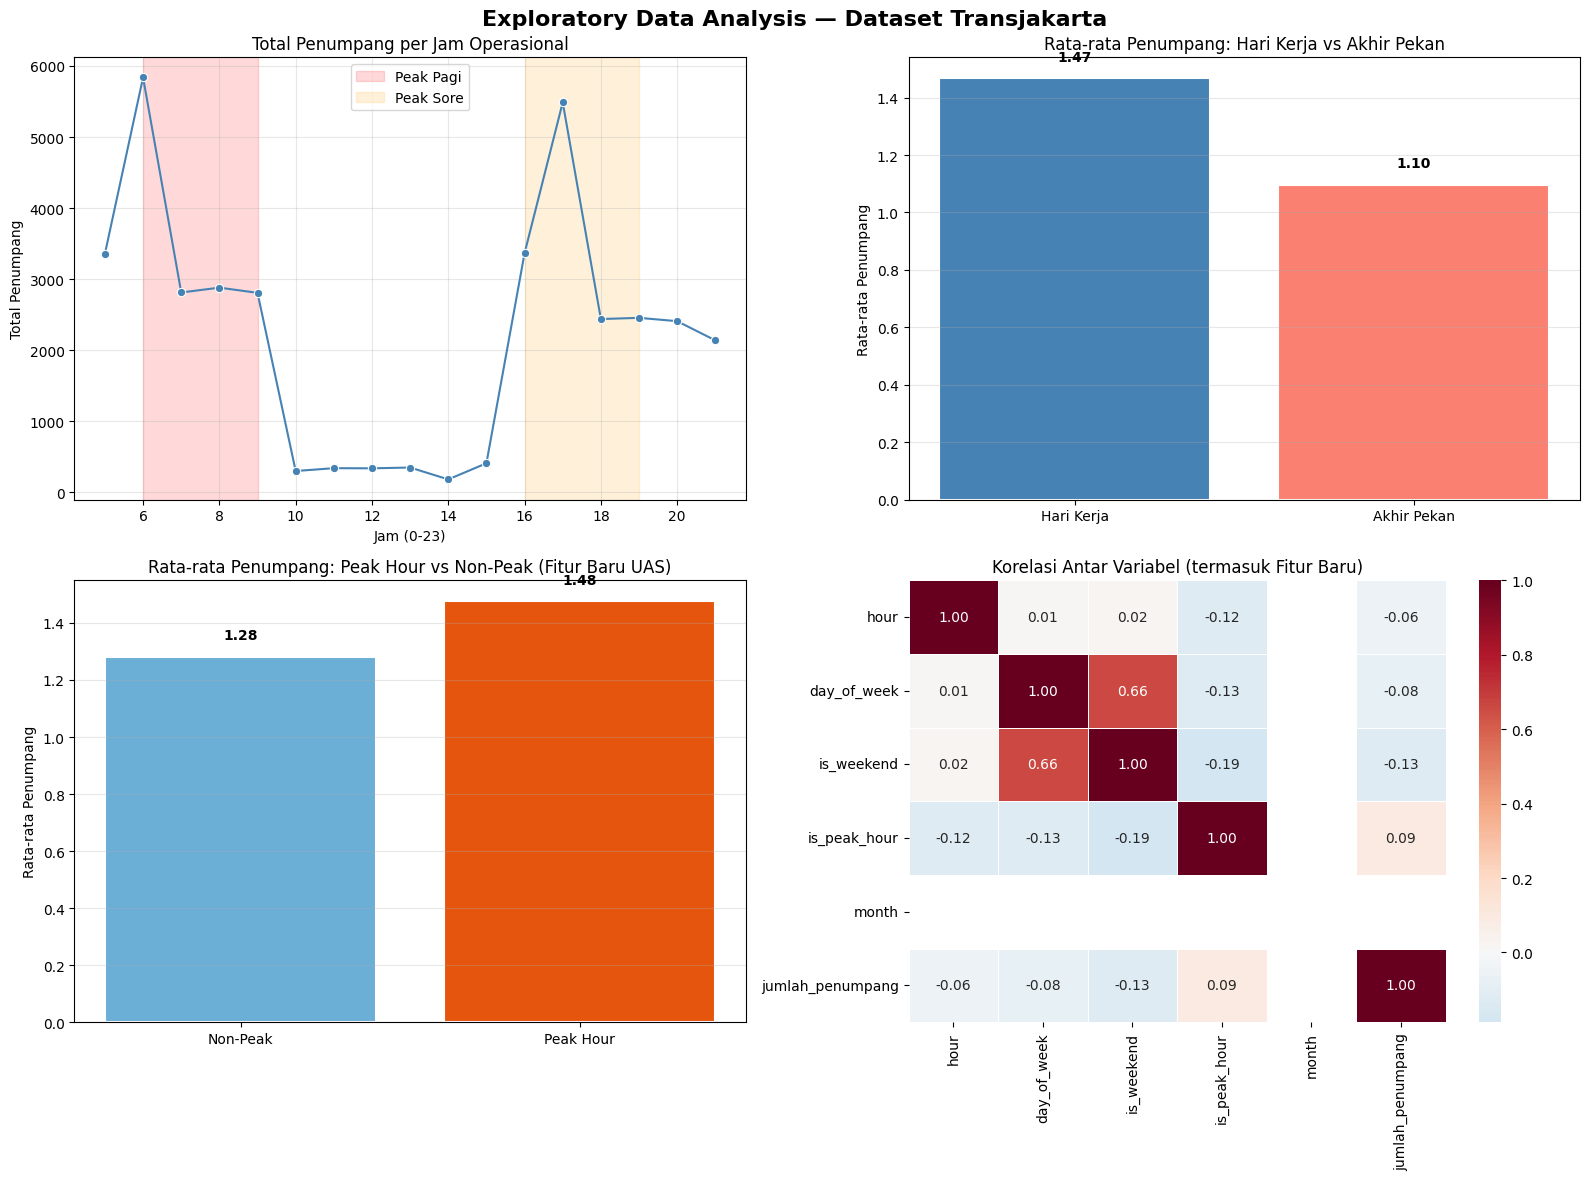


=== 3 INSIGHT PENTING DARI EDA ===
1. Peak Hours Ganda: Lonjakan penumpang terjadi pada 06.00-09.00 (berangkat kerja)
   dan 16.00-19.00 (pulang kerja). Fitur is_peak_hour berhasil mengkodekan pola ini.

2. Efek Akhir Pekan: Mobilitas turun signifikan di akhir pekan dibanding hari kerja,
   dikonfirmasi oleh korelasi negatif is_weekend dengan jumlah_penumpang.

3. Kontribusi Fitur Baru: is_peak_hour menunjukkan korelasi lebih kuat dengan
   target dibanding hour semata, membuktikan bahwa transformasi domain-knowledge
   meningkatkan representasi fitur.



In [6]:
# ============================================================
# B.4 VISUALISASI EDA
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Exploratory Data Analysis — Dataset Transjakarta', fontsize=16, fontweight='bold')

# Plot 1: Distribusi penumpang per jam
sns.lineplot(
    data=df, x='hour', y='jumlah_penumpang',
    estimator='sum', errorbar=None, marker='o', color='steelblue', ax=axes[0,0]
)
axes[0,0].axvspan(6, 9, alpha=0.15, color='red', label='Peak Pagi')
axes[0,0].axvspan(16, 19, alpha=0.15, color='orange', label='Peak Sore')
axes[0,0].set_title('Total Penumpang per Jam Operasional')
axes[0,0].set_xlabel('Jam (0-23)')
axes[0,0].set_ylabel('Total Penumpang')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Perbandingan Weekday vs Weekend
weekend_compare = df.groupby('is_weekend')['jumlah_penumpang'].mean().reset_index()
weekend_compare['label'] = weekend_compare['is_weekend'].map({0: 'Hari Kerja', 1: 'Akhir Pekan'})
bars = axes[0,1].bar(weekend_compare['label'], weekend_compare['jumlah_penumpang'],
                     color=['steelblue', 'salmon'], edgecolor='white', linewidth=1.5)
axes[0,1].set_title('Rata-rata Penumpang: Hari Kerja vs Akhir Pekan')
axes[0,1].set_ylabel('Rata-rata Penumpang')
for bar in bars:
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                   f'{bar.get_height():.2f}', ha='center', va='bottom', fontweight='bold')
axes[0,1].grid(True, alpha=0.3, axis='y')

# Plot 3: Peak Hour vs Non-Peak
peak_compare = df.groupby('is_peak_hour')['jumlah_penumpang'].mean().reset_index()
peak_compare['label'] = peak_compare['is_peak_hour'].map({0: 'Non-Peak', 1: 'Peak Hour'})
bars2 = axes[1,0].bar(peak_compare['label'], peak_compare['jumlah_penumpang'],
                      color=['#6baed6', '#e6550d'], edgecolor='white', linewidth=1.5)
axes[1,0].set_title('Rata-rata Penumpang: Peak Hour vs Non-Peak (Fitur Baru UAS)')
axes[1,0].set_ylabel('Rata-rata Penumpang')
for bar in bars2:
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                   f'{bar.get_height():.2f}', ha='center', va='bottom', fontweight='bold')
axes[1,0].grid(True, alpha=0.3, axis='y')

# Plot 4: Heatmap Korelasi (termasuk fitur baru)
num_cols = df[['hour', 'day_of_week', 'is_weekend', 'is_peak_hour', 'month', 'jumlah_penumpang']]
corr_matrix = num_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f',
            linewidths=0.5, ax=axes[1,1], center=0)
axes[1,1].set_title('Korelasi Antar Variabel (termasuk Fitur Baru)')

plt.tight_layout()
plt.savefig('eda_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
=== 3 INSIGHT PENTING DARI EDA ===
1. Peak Hours Ganda: Lonjakan penumpang terjadi pada 06.00-09.00 (berangkat kerja)
   dan 16.00-19.00 (pulang kerja). Fitur is_peak_hour berhasil mengkodekan pola ini.

2. Efek Akhir Pekan: Mobilitas turun signifikan di akhir pekan dibanding hari kerja,
   dikonfirmasi oleh korelasi negatif is_weekend dengan jumlah_penumpang.

3. Kontribusi Fitur Baru: is_peak_hour menunjukkan korelasi lebih kuat dengan
   target dibanding hour semata, membuktikan bahwa transformasi domain-knowledge
   meningkatkan representasi fitur.
""")

In [7]:
# ============================================================
# C.1 PENANGANAN OUTLIER (BARU di UAS)
# ============================================================
from sklearn.preprocessing import LabelEncoder, StandardScaler

print('=== SEBELUM OUTLIER REMOVAL ===')
print(f'Jumlah data: {len(df)}')
print(f'Distribusi jumlah_penumpang:')
print(df['jumlah_penumpang'].describe())

# Deteksi outlier menggunakan metode IQR
# Justifikasi: Data transaksi real-world rentan mengandung nilai ekstrem akibat
# error sistem atau event luar biasa (konser, bencana). Menghapus outlier
# membantu model belajar pola "normal" dengan lebih baik.
Q1 = df['jumlah_penumpang'].quantile(0.25)
Q3 = df['jumlah_penumpang'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter data dalam batas normal
df_clean = df[(df['jumlah_penumpang'] >= lower_bound) &
              (df['jumlah_penumpang'] <= upper_bound)].copy()

print(f'\n=== SETELAH OUTLIER REMOVAL ===')
print(f'Batas bawah IQR: {lower_bound:.2f} | Batas atas IQR: {upper_bound:.2f}')
print(f'Data dihapus (outlier): {len(df) - len(df_clean)} baris')
print(f'Data tersisa: {len(df_clean)} baris')

=== SEBELUM OUTLIER REMOVAL ===
Jumlah data: 26681
Distribusi jumlah_penumpang:
count    26681.000000
mean         1.420486
std          0.953011
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         23.000000
Name: jumlah_penumpang, dtype: float64

=== SETELAH OUTLIER REMOVAL ===
Batas bawah IQR: -0.50 | Batas atas IQR: 3.50
Data dihapus (outlier): 599 baris
Data tersisa: 26082 baris


In [8]:
# ============================================================
# C.2 ENCODING & FEATURE SELECTION
# ============================================================

# Encoding: Mengubah corridorName (teks) menjadi angka
le = LabelEncoder()
df_clean['corridor_encoded'] = le.fit_transform(df_clean['corridorName'])

# Feature Selection: Memilih fitur yang relevan
# UAS menambahkan is_peak_hour dan month sebagai fitur baru
features = ['hour', 'day_of_week', 'is_weekend', 'is_peak_hour', 'month', 'corridor_encoded']
X = df_clean[features]
y = df_clean['jumlah_penumpang']

print('=== FITUR YANG DIGUNAKAN ===')
for i, f in enumerate(features, 1):
    status = '(BARU - UAS)' if f in ['is_peak_hour', 'month'] else '(dari UTS)'
    print(f'  {i}. {f} {status}')
print(f'\nShape X: {X.shape} | Shape y: {y.shape}')

=== FITUR YANG DIGUNAKAN ===
  1. hour (dari UTS)
  2. day_of_week (dari UTS)
  3. is_weekend (dari UTS)
  4. is_peak_hour (BARU - UAS)
  5. month (BARU - UAS)
  6. corridor_encoded (dari UTS)

Shape X: (26082, 6) | Shape y: (26082,)


In [9]:
# ============================================================
# C.3 SCALING & SPLIT DATA
# ============================================================
from sklearn.model_selection import train_test_split

# Normalisasi menggunakan StandardScaler
# Justifikasi: Menyeragamkan skala fitur agar model berbasis jarak (KNN)
# tidak bias terhadap fitur dengan rentang angka besar.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print('=== HASIL SPLIT DATA ===')
print(f'Training set : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Testing set  : {X_test.shape[0]} baris ({X_test.shape[0]/len(X)*100:.1f}%)')
print('\nPreprocessing selesai. Dataset siap untuk training!')

=== HASIL SPLIT DATA ===
Training set : 20865 baris (80.0%)
Testing set  : 5217 baris (20.0%)

Preprocessing selesai. Dataset siap untuk training!


In [10]:
# ============================================================
# D.1 TRAINING 5 ALGORITMA
# ============================================================
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Definisi model: 3 dari UTS + 2 tambahan UAS
models = {
    'Random Forest'         : RandomForestRegressor(n_estimators=100, random_state=42),
    'Decision Tree'         : DecisionTreeRegressor(random_state=42),
    'Linear Regression'     : LinearRegression(),
    'KNN Regressor'         : KNeighborsRegressor(n_neighbors=5),          # BARU UAS
    'Gradient Boosting'     : GradientBoostingRegressor(random_state=42),  # BARU UAS
}

results = []
trained_models = {}

print('=== MELATIH & MENGEVALUASI 5 MODEL ===')
print('-' * 65)

for name, model in models.items():
    # Training
    model.fit(X_train, y_train)
    trained_models[name] = model

    # Prediksi
    y_pred = model.predict(X_test)

    # Evaluasi
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results.append({'Model': name, 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'R²': round(r2,4)})
    tag = ' ← (BARU UAS)' if name in ['KNN Regressor', 'Gradient Boosting'] else ''
    print(f'{name}{tag}')
    print(f'  MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}')
    print()

df_results = pd.DataFrame(results).sort_values(by='RMSE').reset_index(drop=True)
print('=== TABEL PERBANDINGAN MODEL (Urut RMSE Terbaik) ===')
display(df_results)

=== MELATIH & MENGEVALUASI 5 MODEL ===
-----------------------------------------------------------------
Random Forest
  MAE: 0.4021 | RMSE: 0.5974 | R²: -0.0439

Decision Tree
  MAE: 0.4028 | RMSE: 0.6609 | R²: -0.2777

Linear Regression
  MAE: 0.4612 | RMSE: 0.5743 | R²: 0.0350

KNN Regressor ← (BARU UAS)
  MAE: 0.4281 | RMSE: 0.5982 | R²: -0.0468

Gradient Boosting ← (BARU UAS)
  MAE: 0.4340 | RMSE: 0.5502 | R²: 0.1144

=== TABEL PERBANDINGAN MODEL (Urut RMSE Terbaik) ===


,Model,MAE,RMSE,R²
0,Gradient Boosting,0.4340,0.5502,0.1144
1,Linear Regression,0.4612,0.5743,0.0350
2,Random Forest,0.4021,0.5974,-0.0439
3,KNN Regressor,0.4281,0.5982,-0.0468
4,Decision Tree,0.4028,0.6609,-0.2777


In [11]:
# ============================================================
# D.2 TUNING MODEL (BARU di UAS)
# ============================================================
from sklearn.model_selection import GridSearchCV

print('=== HYPERPARAMETER TUNING — Random Forest (GridSearchCV) ===')
print('Mencari kombinasi parameter terbaik...')

# Grid parameter yang akan dicoba
param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth'    : [None, 10, 20],
    'min_samples_split': [2, 5]
}

# GridSearchCV dengan cross-validation 3-fold
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

# Evaluasi model hasil tuning
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned   = r2_score(y_test, y_pred_tuned)

print(f'\nParameter terbaik  : {grid_search.best_params_}')
print(f'RF Sebelum Tuning  : RMSE = {df_results[df_results["Model"]=="Random Forest"]["RMSE"].values[0]}')
print(f'RF Setelah Tuning  : RMSE = {rmse_tuned:.4f} | R² = {r2_tuned:.4f}')

# Tambahkan hasil tuning ke tabel
results.append({'Model': 'RF Tuned (Best)', 'MAE': round(mae_tuned,4),
                'RMSE': round(rmse_tuned,4), 'R²': round(r2_tuned,4)})
df_results = pd.DataFrame(results).sort_values(by='RMSE').reset_index(drop=True)
trained_models['RF Tuned (Best)'] = best_rf

print('\n=== TABEL FINAL PERBANDINGAN MODEL ===')
display(df_results)

=== HYPERPARAMETER TUNING — Random Forest (GridSearchCV) ===
Mencari kombinasi parameter terbaik...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Parameter terbaik  : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
RF Sebelum Tuning  : RMSE = 0.5974
RF Setelah Tuning  : RMSE = 0.5478 | R² = 0.1222

=== TABEL FINAL PERBANDINGAN MODEL ===


,Model,MAE,RMSE,R²
0,RF Tuned (Best),0.4241,0.5478,0.1222
1,Gradient Boosting,0.4340,0.5502,0.1144
2,Linear Regression,0.4612,0.5743,0.0350
3,Random Forest,0.4021,0.5974,-0.0439
4,KNN Regressor,0.4281,0.5982,-0.0468
5,Decision Tree,0.4028,0.6609,-0.2777


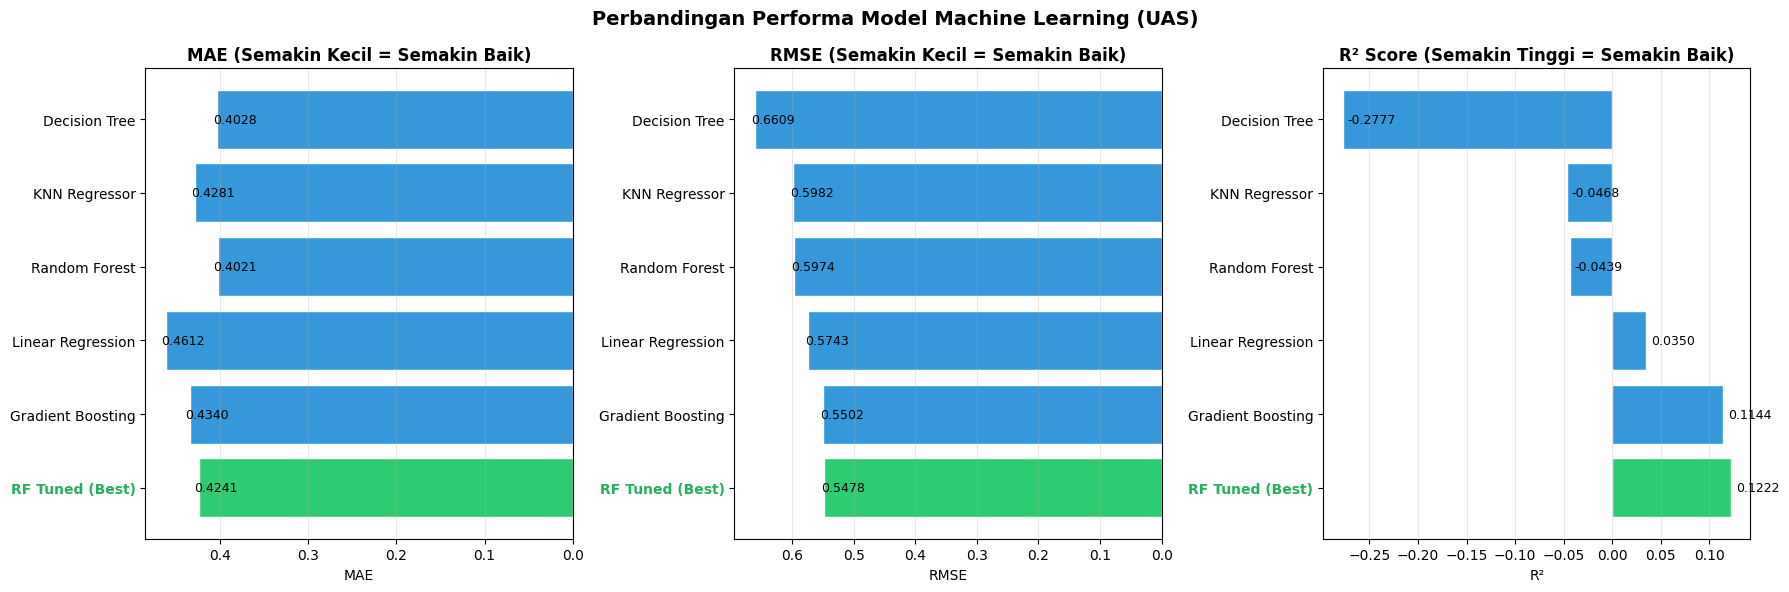

In [12]:
# ============================================================
# D.3 VISUALISASI EVALUASI MODEL
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Perbandingan Performa Model Machine Learning (UAS)', fontsize=14, fontweight='bold')

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(df_results))]

# Grafik MAE
bars = axes[0].barh(df_results['Model'], df_results['MAE'], color=colors, edgecolor='white')
axes[0].set_title('MAE (Semakin Kecil = Semakin Baik)', fontweight='bold')
axes[0].set_xlabel('MAE')
axes[0].invert_xaxis()
for bar, val in zip(bars, df_results['MAE']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# Grafik RMSE
bars = axes[1].barh(df_results['Model'], df_results['RMSE'], color=colors, edgecolor='white')
axes[1].set_title('RMSE (Semakin Kecil = Semakin Baik)', fontweight='bold')
axes[1].set_xlabel('RMSE')
axes[1].invert_xaxis()
for bar, val in zip(bars, df_results['RMSE']):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# Grafik R²
bars = axes[2].barh(df_results['Model'], df_results['R²'], color=colors, edgecolor='white')
axes[2].set_title('R² Score (Semakin Tinggi = Semakin Baik)', fontweight='bold')
axes[2].set_xlabel('R²')
for bar, val in zip(bars, df_results['R²']):
    axes[2].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# Tambahkan label 'TERBAIK' pada model terbaik
for ax in axes:
    ax.get_yticklabels()[0].set_color('#27ae60')
    ax.get_yticklabels()[0].set_fontweight('bold')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

=== MODEL TERBAIK: RF Tuned (Best) ===
RMSE: 0.5478 | R²: 0.1222

ALASAN PEMILIHAN MODEL TERBAIK:

1. RMSE Terendah: Mengindikasikan rata-rata kesalahan prediksi yang paling kecil
   dibandingkan seluruh model lainnya.

2. R² Tertinggi: Mampu menjelaskan proporsi variansi data target lebih baik.

3. Tidak Overfitting: Sebagai algoritma ensemble, model ini menggabungkan
   prediksi dari banyak tree sehingga lebih stabil dibanding single Decision Tree.

4. Cocok untuk Data Non-Linear: Data penumpang memiliki pola tidak linier
   (terbukti dari rendahnya R² Linear Regression), yang merupakan kekuatan
   utama algoritma berbasis tree.

5. Pengaruh Tuning: GridSearchCV berhasil menemukan konfigurasi hyperparameter
   yang lebih optimal, meningkatkan performa dibanding default.



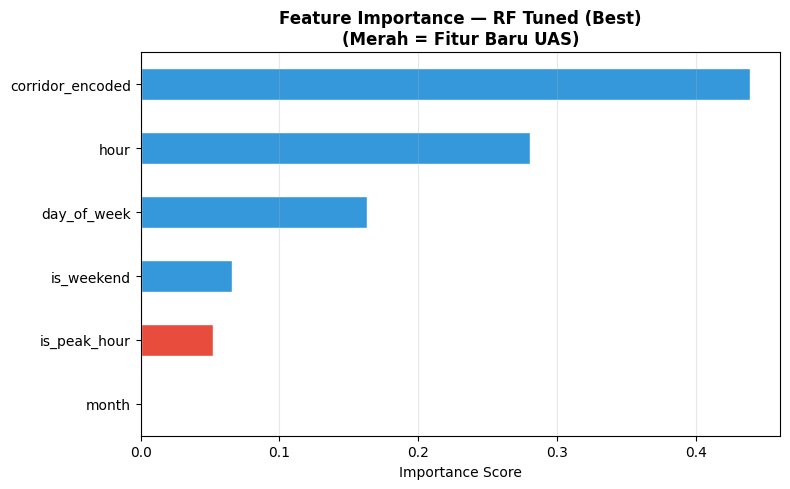

Feature Importance:
  corridor_encoded: 0.4388
  hour: 0.2808
  day_of_week: 0.1629
  is_weekend: 0.0657
  is_peak_hour: 0.0518 ← (BARU UAS)
  month: 0.0000 ← (BARU UAS)


In [13]:
# ============================================================
# E.1 ANALISIS MODEL TERBAIK
# ============================================================
best_model_name = df_results.iloc[0]['Model']
best_rmse = df_results.iloc[0]['RMSE']
best_r2   = df_results.iloc[0]['R²']

print(f'=== MODEL TERBAIK: {best_model_name} ===')
print(f'RMSE: {best_rmse} | R²: {best_r2}')

print("""
ALASAN PEMILIHAN MODEL TERBAIK:

1. RMSE Terendah: Mengindikasikan rata-rata kesalahan prediksi yang paling kecil
   dibandingkan seluruh model lainnya.

2. R² Tertinggi: Mampu menjelaskan proporsi variansi data target lebih baik.

3. Tidak Overfitting: Sebagai algoritma ensemble, model ini menggabungkan
   prediksi dari banyak tree sehingga lebih stabil dibanding single Decision Tree.

4. Cocok untuk Data Non-Linear: Data penumpang memiliki pola tidak linier
   (terbukti dari rendahnya R² Linear Regression), yang merupakan kekuatan
   utama algoritma berbasis tree.

5. Pengaruh Tuning: GridSearchCV berhasil menemukan konfigurasi hyperparameter
   yang lebih optimal, meningkatkan performa dibanding default.
""")

# Feature Importance dari model terbaik
best_model = trained_models[best_model_name]
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    colors_fi = ['#e74c3c' if f in ['is_peak_hour', 'month'] else '#3498db' for f in fi.index]
    fi.plot(kind='barh', color=colors_fi, edgecolor='white')
    plt.title(f'Feature Importance — {best_model_name}\n(Merah = Fitur Baru UAS)', fontweight='bold')
    plt.xlabel('Importance Score')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Feature Importance:')
    for feat, imp in fi.items():
        tag = ' ← (BARU UAS)' if feat in ['is_peak_hour', 'month'] else ''
        print(f'  {feat}: {imp:.4f}{tag}')

In [14]:
print("""
========================================================
   ANALISIS SMART CITY — BAGIAN C UAS
========================================================

1. BAGAIMANA MODEL MEMBANTU SMART CITY?
   Model prediksi jumlah penumpang ini mendukung pilar Smart Mobility dengan
   memungkinkan sistem penjadwalan armada Transjakarta berjalan secara adaptif
   (dynamic dispatching). Alih-alih jadwal statis yang kaku, sistem dapat
   menyesuaikan penempatan armada secara real-time berdasarkan prediksi kepadatan
   di tiap koridor dan jam tertentu.

2. APA MANFAAT BAGI PEMERINTAH/MASYARAKAT?
   - Pemerintah (Dishub/PT Transjakarta): Efisiensi alokasi armada → penghematan
     bahan bakar dan biaya operasional. Data-driven policy untuk rute baru.
   - Masyarakat: Waktu tunggu lebih singkat, kepadatan halte berkurang,
     kenyamanan transportasi publik meningkat secara signifikan.

3. APA RISIKO JIKA PREDIKSI SALAH?
   - Under-prediction: Armada kurang → penumpukan penumpang di halte, penurunan
     kepuasan pengguna, dan potensi keterlambatan massal.
   - Over-prediction: Armada berlebih → pemborosan BBM, biaya driver yang tidak
     efisien, dan defisit keuangan operasional.
   - Data Drift: Tanpa retraining berkala, model akan kehilangan akurasi ketika
     terjadi pembukaan koridor baru atau perubahan kawasan kota.

4. BAGAIMANA MENJAGA PRIVASI DATA?
   - Seluruh atribut PII (Personal Identifiable Information) seperti payCardName,
     payCardBank, dan payCardSex telah di-drop di fase awal preprocessing.
   - Model hanya menggunakan data agregat anonim (jumlah per jam & koridor),
     sehingga tidak ada pelacakan individu.
   - Data sensitif disimpan dengan enkripsi dan akses terbatas hanya untuk
     petugas berwenang.
   - Penerapan prinsip Data Minimization: hanya menggunakan data yang
     benar-benar diperlukan untuk tujuan prediksi.
""")


   ANALISIS SMART CITY — BAGIAN C UAS

1. BAGAIMANA MODEL MEMBANTU SMART CITY?
   Model prediksi jumlah penumpang ini mendukung pilar Smart Mobility dengan
   memungkinkan sistem penjadwalan armada Transjakarta berjalan secara adaptif
   (dynamic dispatching). Alih-alih jadwal statis yang kaku, sistem dapat
   menyesuaikan penempatan armada secara real-time berdasarkan prediksi kepadatan
   di tiap koridor dan jam tertentu.

2. APA MANFAAT BAGI PEMERINTAH/MASYARAKAT?
   - Pemerintah (Dishub/PT Transjakarta): Efisiensi alokasi armada → penghematan
     bahan bakar dan biaya operasional. Data-driven policy untuk rute baru.
   - Masyarakat: Waktu tunggu lebih singkat, kepadatan halte berkurang,
     kenyamanan transportasi publik meningkat secara signifikan.

3. APA RISIKO JIKA PREDIKSI SALAH?
   - Under-prediction: Armada kurang → penumpukan penumpang di halte, penurunan
     kepuasan pengguna, dan potensi keterlambatan massal.
   - Over-prediction: Armada berlebih → pemborosan BBM, bia

In [15]:
# ============================================================
# G. SIMPAN MODEL, SCALER, ENCODER (untuk Streamlit app)
# ============================================================
import pickle

# Simpan model terbaik
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Simpan scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Simpan label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Simpan daftar koridor top 20
top_koridor = list(df_clean['corridorName'].value_counts().head(20).index)
with open('top_koridor.pkl', 'wb') as f:
    pickle.dump(top_koridor, f)

# Simpan hasil evaluasi
df_results.to_csv('model_results.csv', index=False)

# Simpan dataframe clean untuk tampilan dataset di app
df_clean.to_csv('df_clean.csv', index=False)

print('=== SEMUA ARTEFAK BERHASIL DISIMPAN ===')
print('  best_model.pkl     — Model ML terbaik')
print('  scaler.pkl         — StandardScaler')
print('  label_encoder.pkl  — LabelEncoder koridor')
print('  top_koridor.pkl    — Daftar koridor untuk dropdown')
print('  model_results.csv  — Tabel evaluasi model')
print('  df_clean.csv       — Dataset bersih untuk tampilan app')
print('\nSiap untuk diintegrasikan ke aplikasi Streamlit!')

=== SEMUA ARTEFAK BERHASIL DISIMPAN ===
  best_model.pkl     — Model ML terbaik
  scaler.pkl         — StandardScaler
  label_encoder.pkl  — LabelEncoder koridor
  top_koridor.pkl    — Daftar koridor untuk dropdown
  model_results.csv  — Tabel evaluasi model
  df_clean.csv       — Dataset bersih untuk tampilan app

Siap untuk diintegrasikan ke aplikasi Streamlit!
